# Regularization

## Definition
Regularization is a technique used to reduce **overfitting** by adding a penalty to large coefficient values.

## Why Use Regularization?
- Reduces overfitting
- Improves model generalization
- Handles multicollinearity
- Controls large coefficients

---

# Types of Regularization

## 1. Ridge Regression (L2)

### Formula

Loss = RSS + λΣ(β²)

### Formula Terms

- **RSS** → Model prediction error.
- **β** → Feature coefficient (weight).
- **Σ** → Sum of all coefficients.
- **λ (Lambda)** → Controls penalty strength.
- **β²** → Penalizes large coefficients.

### How it Works

- Shrinks coefficients toward zero.
- Keeps all features in the model.
- Useful for handling multicollinearity.

### Illustration

Before Ridge:

| Feature | Coefficient |
|----------|------------|
| TV | 10 |
| Radio | 8 |
| Newspaper | 6 |

After Ridge:

| Feature | Coefficient |
|----------|------------|
| TV | 7 |
| Radio | 5 |
| Newspaper | 3 |

**Result:** Coefficients become smaller, but no feature is removed.

---

## 2. Lasso Regression (L1)

### Formula

Loss = RSS + λΣ|β|

### Formula Terms

- **RSS** → Model prediction error.
- **β** → Feature coefficient (weight).
- **Σ** → Sum of all coefficients.
- **λ (Lambda)** → Controls penalty strength.
- **|β|** → Penalizes large coefficients using absolute values.

### How it Works

- Shrinks coefficients toward zero.
- Can make coefficients exactly zero.
- Performs automatic feature selection.

### Illustration

Before Lasso:

| Feature | Coefficient |
|----------|------------|
| TV | 10 |
| Radio | 8 |
| Newspaper | 6 |

After Lasso:

| Feature | Coefficient |
|----------|------------|
| TV | 7 |
| Radio | 0 |
| Newspaper | 2 |

**Result:** Features with coefficient 0 are removed from the model.

---

# Ridge vs Lasso

| Ridge (L2) | Lasso (L1) |
|------------|------------|
| Uses β² penalty | Uses \|β\| penalty |
| Keeps all features | Can remove features |
| Reduces coefficients | Reduces coefficients |
| Good for multicollinearity | Good for feature selection |

---

# Memory Trick

**Ridge → Reduce coefficients**

**Lasso → Remove coefficients**

---

# Interview Definition

Regularization is a technique used to prevent overfitting by penalizing large coefficient values. Ridge (L2) shrinks coefficients, while Lasso (L1) can shrink coefficients to zero and perform feature selection.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/communities/communities.data'
crime = pd.read_csv(url, header=None, na_values=['?'])
crime.head()

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,8,NaN,NaN,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,NaN,NaN,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,NaN,NaN,NaN,NaN,0.00,NaN,0.67
2,24,NaN,NaN,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.43
3,34,5.0,81440.0,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,NaN,NaN,NaN,NaN,0.00,NaN,0.12
4,42,95.0,6096.0,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.03


In [3]:
crime.shape

(1994, 128)

<Axes: >

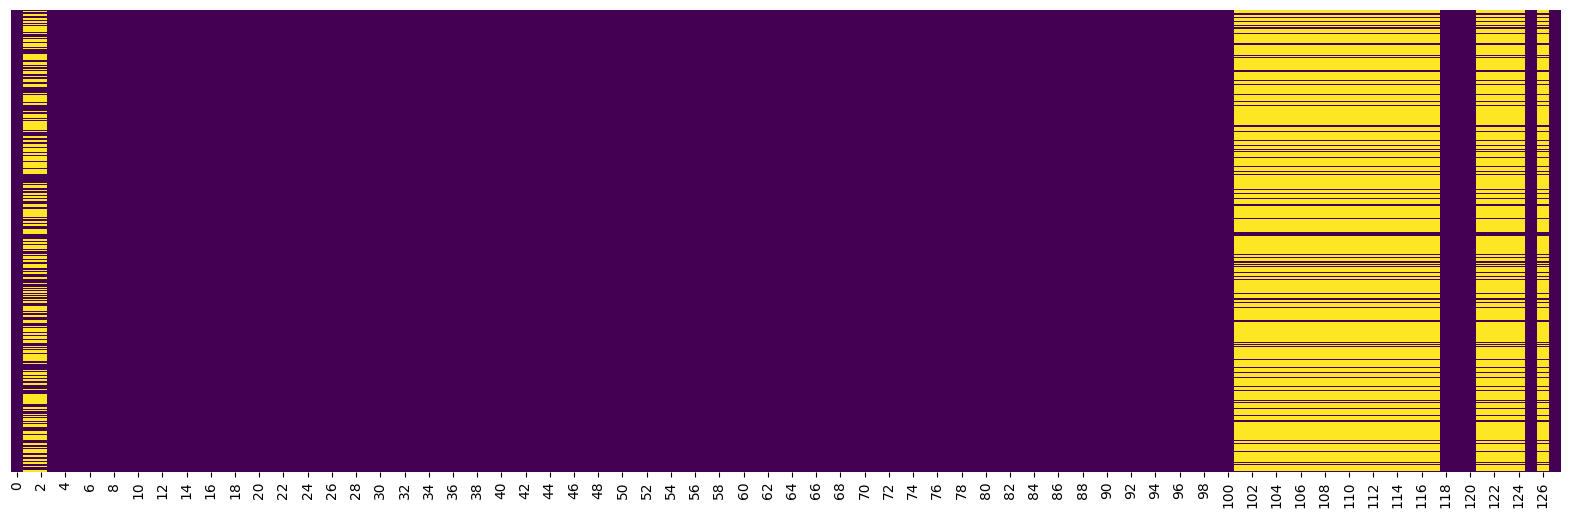

In [4]:
plt.figure(figsize=(20,6))
sns.heatmap(crime.isnull(),yticklabels=False,cbar = False,cmap = 'viridis')


<Axes: >

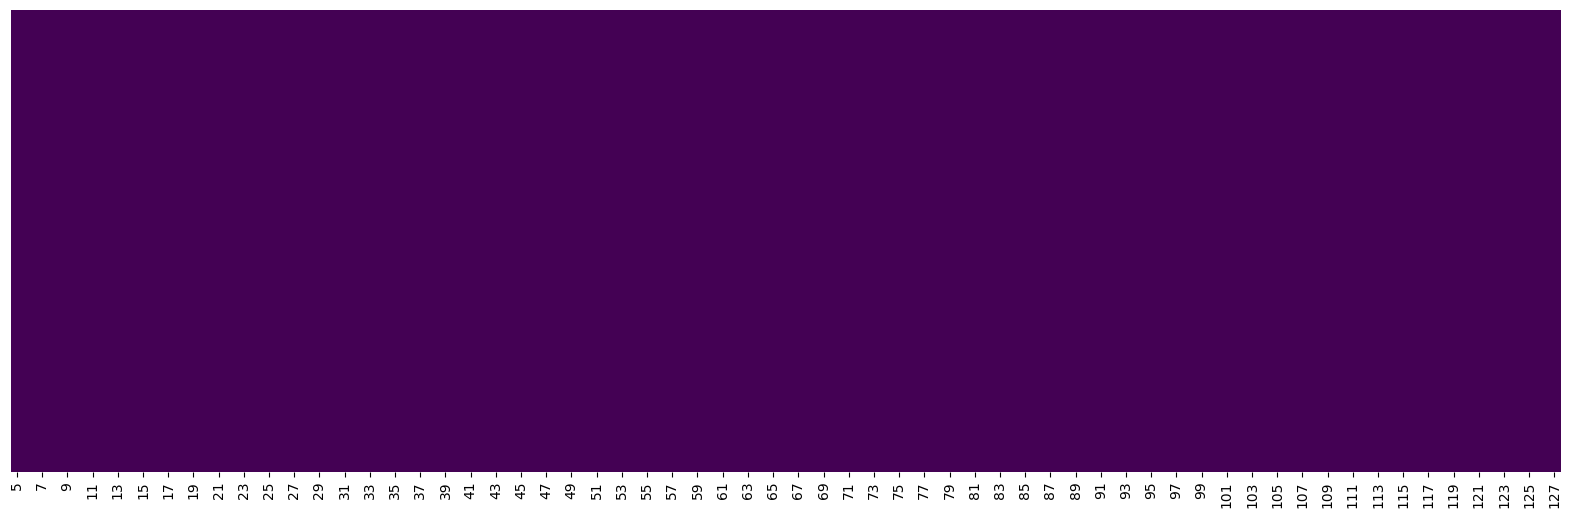

In [5]:
crime.drop([0,1,2,3,4],axis = 1,inplace = True)

crime.dropna(inplace=True)
plt.figure(figsize=(20, 6))
sns.heatmap(crime.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [6]:
crime.shape

(319, 123)

In [7]:
x = crime.drop(127,axis = 1)
y = crime[127]

In [8]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.1,random_state = 42)

In [9]:
from sklearn.linear_model import LinearRegression

linReg = LinearRegression()
linReg.fit(x_train,y_train)
LinearRegression(copy_X=True,n_jobs=False,fit_intercept=True)

print("Intercept:",linReg.intercept_)
print("coefficint:",linReg.coef_)

Intercept: 2.6448428791937646
coefficint: [-4.23084333e+00  1.11265892e+00 -9.83344927e-02  1.77948352e-01
 -6.38427704e-02  1.66778517e-01 -4.76889873e-01 -1.89250902e+00
  1.37245341e+00  3.23630172e-01  4.51796020e+00 -1.66626242e-01
  4.25026429e-01 -8.15045349e-01 -3.19625582e-01 -8.24483867e-01
 -8.91772868e-01  2.49062819e-01  3.85934789e-02  2.89173860e-01
 -1.13551812e+00  5.35832078e-01 -3.51004661e-01 -8.54285351e-02
 -2.83999608e-01  1.03667206e-01 -6.90700701e-02 -4.89859820e-01
  5.31172951e-01 -1.39543265e-01 -7.36106669e-01 -2.31269370e-01
  2.34991394e-01  1.21360383e+00 -2.72203959e-01  6.67957600e-02
  7.14368022e-01  8.05167293e-01 -1.01595347e-01 -1.21774174e-01
 -1.84113131e-01 -2.86613982e-01 -1.52993471e-01 -8.21788441e-01
 -8.90704143e-01  4.24386953e-01 -1.16659256e-02 -1.97143087e-01
  2.41953283e-02  4.68117154e-02 -1.18373903e-01 -8.62134000e-02
  5.45808746e-01 -7.08266519e-01 -4.23038209e-01  9.00662291e-01
 -4.67019768e-01  7.34866606e-02  2.29110761e+00

In [10]:
y_pred = linReg.predict(x_test)

from sklearn.metrics import r2_score
from sklearn import metrics

print("R2 value:",r2_score(y_test,y_pred))
print("MAE:,",metrics.mean_absolute_error(y_test,y_pred))
print("MSE",metrics.mean_squared_error(y_test,y_pred))
print("RMSE:",np.sqrt(metrics.mean_squared_error(y_test,y_pred)))

R2 value: 0.43651988815216336
MAE:, 0.1695717851250032
MSE 0.049309572303315584
RMSE: 0.22205758780846824


### Ridge Regression

In [11]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge

scaler = MinMaxScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model = Ridge(alpha=0)
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)

We normalize (standardize) data before Ridge Regression because the L2 penalty is applied directly to the coefficients. If features have different scales, larger-scale features may receive smaller coefficients and be penalized less, making regularization unfair. Standardization puts all features on the same scale so Ridge can apply the penalty uniformly and produce more reliable coefficients.

In [12]:
from sklearn import metrics
print("R-Square Value",r2_score(y_test,y_pred))
print("\n")
print ("mean_absolute_error :",metrics.mean_absolute_error(y_test, y_pred))
print("\n")
print ("mean_squared_error : ",metrics.mean_squared_error(y_test, y_pred))
print("\n")
print ("root_mean_squared_error : ",np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

R-Square Value 0.4365198881355139


mean_absolute_error : 0.1695717851266856


mean_squared_error :  0.04930957230477256


root_mean_squared_error :  0.22205758781174886


In [13]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge

scaler = MinMaxScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model = Ridge(alpha=0.1)
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)

In [14]:
from sklearn import metrics
print("R-Square Value",r2_score(y_test,y_pred))
print("\n")
print ("mean_absolute_error :",metrics.mean_absolute_error(y_test, y_pred))
print("\n")
print ("mean_squared_error : ",metrics.mean_squared_error(y_test, y_pred))
print("\n")
print ("root_mean_squared_error : ",np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

R-Square Value 0.6401627039147068


mean_absolute_error : 0.13583345692932747


mean_squared_error :  0.03148899632067017


root_mean_squared_error :  0.17745139143063987


In [15]:
print(model.coef_)

[-3.18939173e-02  3.43399863e-01 -5.60085280e-02  5.26641147e-02
 -2.81332951e-02  1.30173098e-01  7.83261774e-02 -3.58779190e-01
  1.21896400e-01  2.05923479e-01  7.79064160e-02 -5.01912987e-02
  6.66738756e-02 -3.31234907e-01 -1.42265882e-01 -6.08249790e-01
 -2.05300527e-01  1.51798274e-01 -4.18038981e-02  1.08904543e-02
 -3.14100591e-01  2.68565570e-01 -2.10427011e-01  3.81126856e-02
 -1.49340282e-01  9.65130372e-02  7.36330162e-03 -3.30534883e-01
  9.33973748e-02 -2.17007775e-01 -3.56589884e-01 -5.30003402e-03
  1.58680203e-01  3.09590824e-01 -1.90804164e-01  6.32086244e-02
  3.74213308e-01  1.89652735e-01 -5.56386063e-02 -4.93476211e-02
 -6.12350021e-02 -1.24844709e-01  2.20146215e-01 -2.17531061e-01
 -3.48582640e-01  7.47228672e-02 -1.50868115e-01 -6.67998780e-02
  1.06457102e-01 -2.42997615e-02  1.55361820e-01 -8.77277419e-02
  9.73208306e-02 -2.93578194e-01  7.12068359e-02  2.33737486e-01
 -5.39009599e-02  3.64537257e-03  1.66073045e-01 -2.07856600e-01
 -1.82156725e-03  1.17833

In [16]:
alpha_range = 10.**np.arange(-2,3)
alpha_range

from sklearn.linear_model import RidgeCV
RidgeRegcv = RidgeCV(alphas = alpha_range,scoring = "neg_mean_squared_error")
RidgeRegcv.fit(x_train, y_train)
RidgeRegcv.alpha_

10.0

In [17]:
y_pred = RidgeRegcv.predict(x_test_scaled)


from sklearn import metrics
print("R-Square Value",r2_score(y_test,y_pred))
print("\n")
print ("mean_absolute_error :",metrics.mean_absolute_error(y_test, y_pred))
print("\n")
print ("mean_squared_error : ",metrics.mean_squared_error(y_test, y_pred))
print("\n")
print ("root_mean_squared_error : ",np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

R-Square Value 0.7060298825331379


mean_absolute_error : 0.12162012378345805


mean_squared_error :  0.025725026416124543


root_mean_squared_error :  0.1603902316730185


### Lasso Regression

In [18]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Lasso

scaler = MinMaxScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

lassoreg = Lasso(alpha = 0.001)
lassoreg.fit(x_train_scaled,y_train)
print(lassoreg.coef_)

[-0.          0.          0.07628261 -0.08089653 -0.          0.04977415
 -0.         -0.01981719 -0.          0.         -0.         -0.
 -0.         -0.00421736 -0.         -0.22262515  0.          0.
 -0.          0.          0.          0.         -0.         -0.
 -0.          0.          0.         -0.03008879 -0.         -0.02606038
 -0.         -0.          0.02705237 -0.         -0.07508162  0.
  0.         -0.          0.         -0.          0.          0.
  0.         -0.43525324 -0.         -0.         -0.          0.
  0.         -0.          0.06237697 -0.         -0.         -0.
  0.          0.00791638  0.          0.          0.00916074  0.
 -0.          0.          0.          0.         -0.          0.
 -0.          0.          0.          0.05792277 -0.          0.
 -0.          0.          0.01069085  0.          0.          0.
 -0.         -0.         -0.         -0.         -0.04943825 -0.
 -0.          0.         -0.         -0.01155581 -0.          0.
  0.16872

In [19]:
lassoreg = Lasso(alpha = 0.01)
lassoreg.fit(x_train_scaled,y_train)
print(lassoreg.coef_)

[ 0.          0.          0.         -0.20702274 -0.          0.
  0.          0.          0.         -0.          0.         -0.
 -0.         -0.         -0.         -0.         -0.          0.
 -0.         -0.         -0.         -0.         -0.         -0.
 -0.         -0.         -0.          0.          0.          0.
  0.         -0.          0.         -0.         -0.          0.
  0.         -0.          0.          0.          0.03197781  0.
  0.         -0.         -0.33554128 -0.         -0.         -0.
 -0.          0.          0.12354769  0.          0.          0.
  0.          0.          0.          0.          0.          0.
 -0.          0.          0.          0.          0.          0.
  0.         -0.          0.          0.         -0.          0.05292429
 -0.         -0.          0.00207812  0.          0.          0.
  0.         -0.         -0.         -0.         -0.         -0.
 -0.         -0.          0.         -0.         -0.          0.
  0.03669807  0. 

In [20]:
# calculate RMSE (for alpha=0.01)
y_pred = lassoreg.predict(x_test_scaled)


from sklearn import metrics
print("R-Square Value",r2_score(y_test,y_pred))
print("\n")
print ("mean_absolute_error :",metrics.mean_absolute_error(y_test, y_pred))
print("\n")
print ("mean_squared_error : ",metrics.mean_squared_error(y_test, y_pred))
print("\n")
print ("root_mean_squared_error : ",np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

R-Square Value 0.6787401377655882


mean_absolute_error : 0.13685863750063065


mean_squared_error :  0.028113124264585794


root_mean_squared_error :  0.16766968797187462


In [24]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LassoCV

# Scaling
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

# LassoCV
lassoregcv = LassoCV(
    n_alphas=100,
    random_state=1
)

lassoregcv.fit(X_train_scaled, y_train)

print("Best Alpha:", lassoregcv.alpha_)

Best Alpha: 0.0039034595814609083


In [25]:
print(lassoregcv.coef_)

[ 0.          0.          0.         -0.22510273 -0.          0.
  0.         -0.          0.          0.          0.         -0.
 -0.         -0.         -0.         -0.06800084  0.          0.
 -0.         -0.         -0.         -0.         -0.         -0.
 -0.         -0.         -0.          0.          0.          0.
  0.         -0.          0.         -0.         -0.          0.
  0.         -0.          0.          0.          0.06509764  0.
  0.         -0.10172551 -0.34421836 -0.         -0.         -0.
 -0.          0.          0.0391369   0.          0.          0.
  0.          0.          0.          0.          0.          0.
 -0.          0.          0.          0.          0.          0.
  0.         -0.          0.          0.         -0.          0.03299722
 -0.         -0.          0.01308913  0.          0.          0.
  0.         -0.         -0.         -0.         -0.         -0.
 -0.         -0.          0.         -0.         -0.          0.
  0.14720926  0. 

In [26]:
# predict method uses the best alpha value
y_pred = lassoregcv.predict(x_test_scaled)


from sklearn import metrics
print("R-Square Value",r2_score(y_test,y_pred))
print("\n")
print ("mean_absolute_error :",metrics.mean_absolute_error(y_test, y_pred))
print("\n")
print ("mean_squared_error : ",metrics.mean_squared_error(y_test, y_pred))
print("\n")
print ("root_mean_squared_error : ",np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

R-Square Value 0.723131309186541


mean_absolute_error : 0.11907307751699224


mean_squared_error :  0.024228497938321686


root_mean_squared_error :  0.1556550607539687


alpha in Lasso Regression is the regularization parameter that controls the strength of the L1 penalty. A larger alpha increases regularization, causing more coefficients to shrink to zero and performing stronger feature selection. A smaller alpha applies weaker regularization and behaves more like ordinary linear regression.

### Conclusion

We learned two different types of regression techniques, namely Lasso and Ridge Regression which can be proved effective for overfitting. These techniques make a good fit model by adding a penalty and shrinking the beta coefficients. It is necessary to have a correct balance of the Bias and Variance to control overfitting.